# Differential Manchester Encoding with Plotting

In [1]:
import matplotlib.pyplot as plt

bits = "10110010"

In [2]:
# ----------------------------------------------
# Differential Manchester Encoding function
# Convention:
# 0 -> transition at beginning
# 1 -> no transition at beginning

# Always transition in the middle

# Initial level = High (+1)
# ----------------------------------------------

def differential_manchester(bits):
    signal = []
    level = 1
    for bit in bits:
        if bit == "0":
            level = -level
        signal.append(level)

        level = -level
        signal.append(level)

    return signal

In [6]:
# Generating signal
signal = differential_manchester(bits)

print("Bit Stream  :", bits)
print("\nDifferential Manchester Signal: ", signal)

Bit Stream  : 10110010

Differential Manchester Signal:  [1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, -1, 1]


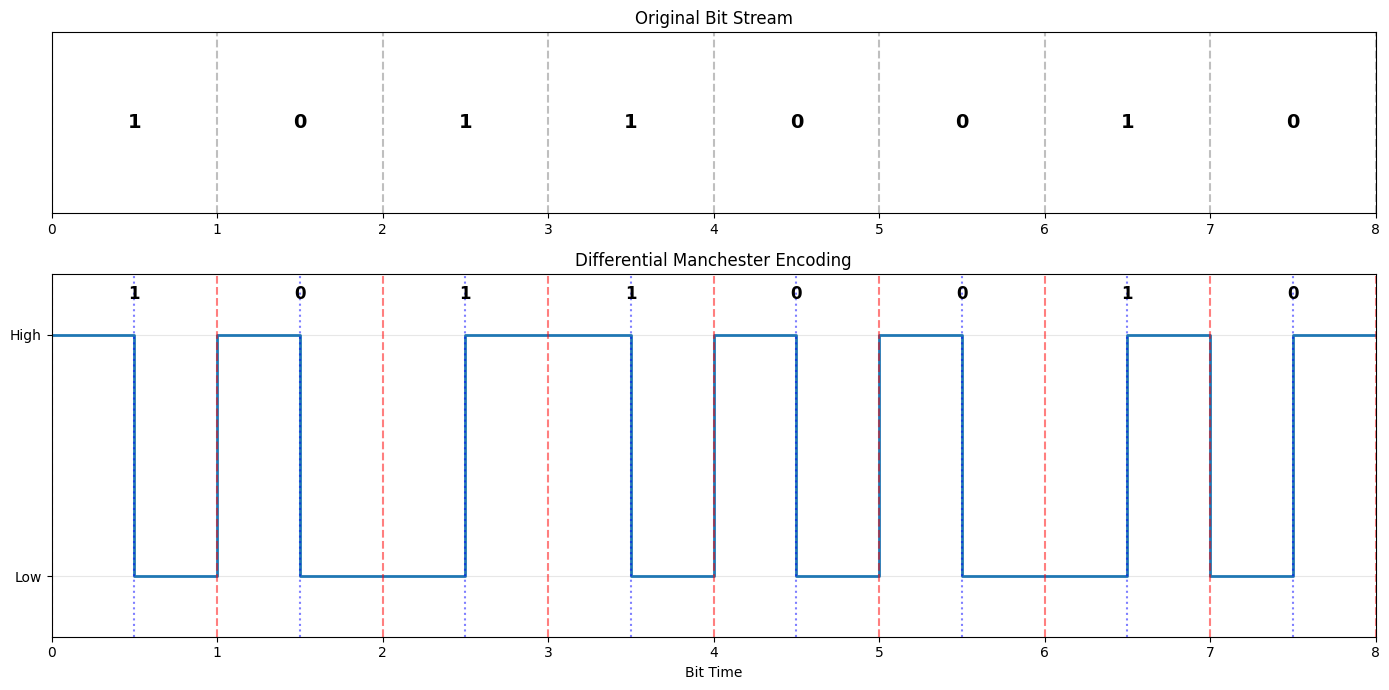

In [43]:
# Creating the subplots
fig, axes = plt.subplots(2, 1,
                        figsize = (14,7),
                        gridspec_kw = {'height_ratios': [1,2]})


# Plotting the original stream

axes[0].set_xlim(0, len(bits))
axes[0].set_ylim(-1,1)

for i,bit in enumerate(bits):
    axes[0].axvline(i, color='gray', linestyle='--', alpha=0.5)
    axes[0].text(i+0.5, 0, bit, ha='center', va='center', fontsize=14, fontweight='bold')

axes[0].axvline(len(bits), color='gray', linestyle='--', alpha=0.5)

axes[0].set_yticks([])
axes[0].set_title("Original Bit Stream")



# Plotting Differential Manchester signal

t = []
for i in range(len(signal)):
    start = i / 2
    end = (i+1) / 2
    t.extend([start, end])

y = []
for value in signal:
    y.extend([value, value])

axes[1].plot(t, y, drawstyle='steps-post', linewidth=2)

# Bit boundaries
for i in range(len(bits) + 1):
    axes[1].axvline(i, color='red', linestyle='--', alpha=0.5)

# Middle bit transition
for i in range(len(bits)):
    axes[1].axvline(i+0.5, color='blue', linestyle=':', alpha = 0.5)

# Bit labels
for i,bit in enumerate(bits):
    axes[1].text(i+0.5, 1.3, bit, ha='center', fontsize=12, fontweight='bold')

axes[1].set_xlim(0, len(bits))
axes[1].set_ylim(-1.5, 1.5)

axes[1].set_yticks([-1,1])
axes[1].set_yticklabels(['Low', 'High'])

axes[1].set_xlabel("Bit Time")
axes[1].set_title("Differential Manchester Encoding")

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()